# Домашнее задание 6. Подключение очереди и асинхронной обработки

In [ ]:
#%%capture
# import warnings
# warnings.filterwarnings('ignore', category=DeprecationWarning)
# !apt-get update -y >/dev/null
# !curl -fsSL https://deb.nodesource.com/setup_22.x | sudo -E bash -
# !apt install nodejs -y
# !apt-get install -y npm  >/dev/null
# !npm install -g npm@11.7.0
# !npm install -g pnpm
# !rm -rf studio
# !git clone https://github.com/asyncapi/studio.git

In [ ]:
# from google.colab import userdata
# import os
# os.environ["tunatoken"] = userdata.get('tuna')
# !curl -sSLf https://get.tuna.am | sh >/dev/null
# !tuna config save-token $tunatoken

asyncapi studio использован не локальный, а публичный https://studio.asyncapi.com/

## 1. Оценить необходимость асинхронной обработки

* Параллелизм данных — это одновременное выполнение на нескольких ядрах одной и той же функции в разных элементах набора данных (он же SIMD, single-instruiction-multiple-data).

    *В [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd) код был неоптимальный, поскольку при наличии вычислительных мощностей можно выполнять заблюривание каждого кадра **одновременно.***


* Параллелизм задач — это одновременное выполнение на нескольких ядрах множества различных функций в одном и том же или разных наборах данных.

    *Если бы мы в [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd) распараллелили данные, то могли бы выполнять заблюривание каждого кадра **асинхронно**, по цепочке gray = cv2.cvtColor(frame) -> faces = face_cascade.detectMultiScale(gray) -> apply_mosaic_effect*

Асинхронный код писать сложнее, но сегодня он является основой всех серверов в машинном обучении. Напишите в ячейке ниже свою оценку выигрыша (можно методом HDD) от асинхронной обработки конвейера ML в [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=1JM7AcPIaERg)*


In [3]:
# Грубая оценка времени на 1 кадр, мс
t_gray = 2
t_detect = 35
t_blur = 8
t_write = 5

sync_total = t_gray + t_detect + t_blur + t_write
sync_fps = 1000 / sync_total

# Предположим 4 воркера для параллельной обработки кадров/чанков видео.
# Идеального ускорения не будет из-за очереди, сериализации, чтения/записи и сборки результата.
overhead_coeff = 0.75
async_fps = sync_fps * 4 * overhead_coeff
speedup = async_fps / sync_fps

print(f"Синхронная обработка: ~{sync_total} мс/кадр, ~{sync_fps:.1f} fps")
print(f"Асинхронная обработка (4 воркера): ~{async_fps:.1f} fps")
print(f"Ожидаемый выигрыш по пропускной способности: ~x{speedup:.1f}")

Синхронная обработка: ~50 мс/кадр, ~20.0 fps
Асинхронная обработка (4 воркера): ~60.0 fps
Ожидаемый выигрыш по пропускной способности: ~x3.0


Для конвейера из HW5 асинхронная обработка оправдана, потому что кадры видео обрабатываются независимо и их можно распараллелить между воркерами. Наибольшую стоимость имеет detectMultiScale, поэтому именно этот этап сильнее всего выигрывает от распределения по очереди и пулу воркеров. При этом асинхронность нужна не всегда: для одного короткого видео или единичного запроса синхронный код проще и может быть достаточным. Но для длинных видео и нескольких одновременных задач асинхронная архитектура с брокером очередей повышает throughput, позволяет не блокировать API и даёт ориентировочный выигрыш при данных вводных порядка 2-3x. 

## 2. Выбрать брокер очередей, спроектировать асинхронный API для модели

* Обоснуйте свой выбор брокера (Redis/Kafka/RabbitMQ) для асинхронной обработки конвейера ML.
* Создайте цепочку из 3 событий gray = cv2.cvtColor(frame) -> faces = face_cascade.detectMultiScale(gray) -> apply_mosaic_effect и опишите цепочку в формате AsyncApi.
* Полученное описание скопируйте или скачайте, как показано на рисунке, и вставьте в этот блокнот в ячейку ниже.

%%html
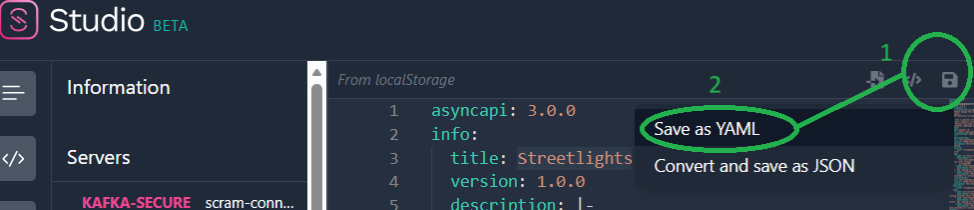

In [ ]:
# %cd studio
# !pnpm install  >/dev/null
# !echo "Скопируйте адрес Public address, вставьте его в адресную строку браузера, нажмите Enter"
# !sleep 15 & pnpm run studio & tuna http 8000 & wait

Если не получилось запустить из блокнота, то можно **на локальной машине** поднять контейнер, скопировав docker-compose.yaml
```yaml
name: project_asyncapi_studio
services:
    studio:
        ports:
            - 8000:80
        image: asyncapi/studio
```


*Ожидаемый артефакт: YAML в [ячейке](#scrollTo=aBYphRLZ3x4H)*


Выбираем RabbitMQ. В этом сценарии каждый кадр или чанк видео представляет собой отдельную задачу, которую нужно надежно доставить воркеру, обработать и при необходимости повторить. RabbitMQ подходит лучше Kafka, потому что здесь не нужен сверхвысокий поток событий и длительное хранение event log, а важнее удобная модель очередей и подтверждений доставки. По сравнению с Redis это более естественный выбор для task queue, так как RabbitMQ изначально спроектирован как брокер сообщений с поддержкой routing, ack и retry.

Для разработки была использована не локальная версия студии, а публичный веб сервис https://studio.asyncapi.com/. Валидация прошла без ошибок, но потребовала несколько нефункиональных разделов типа contact, license и т.п. 
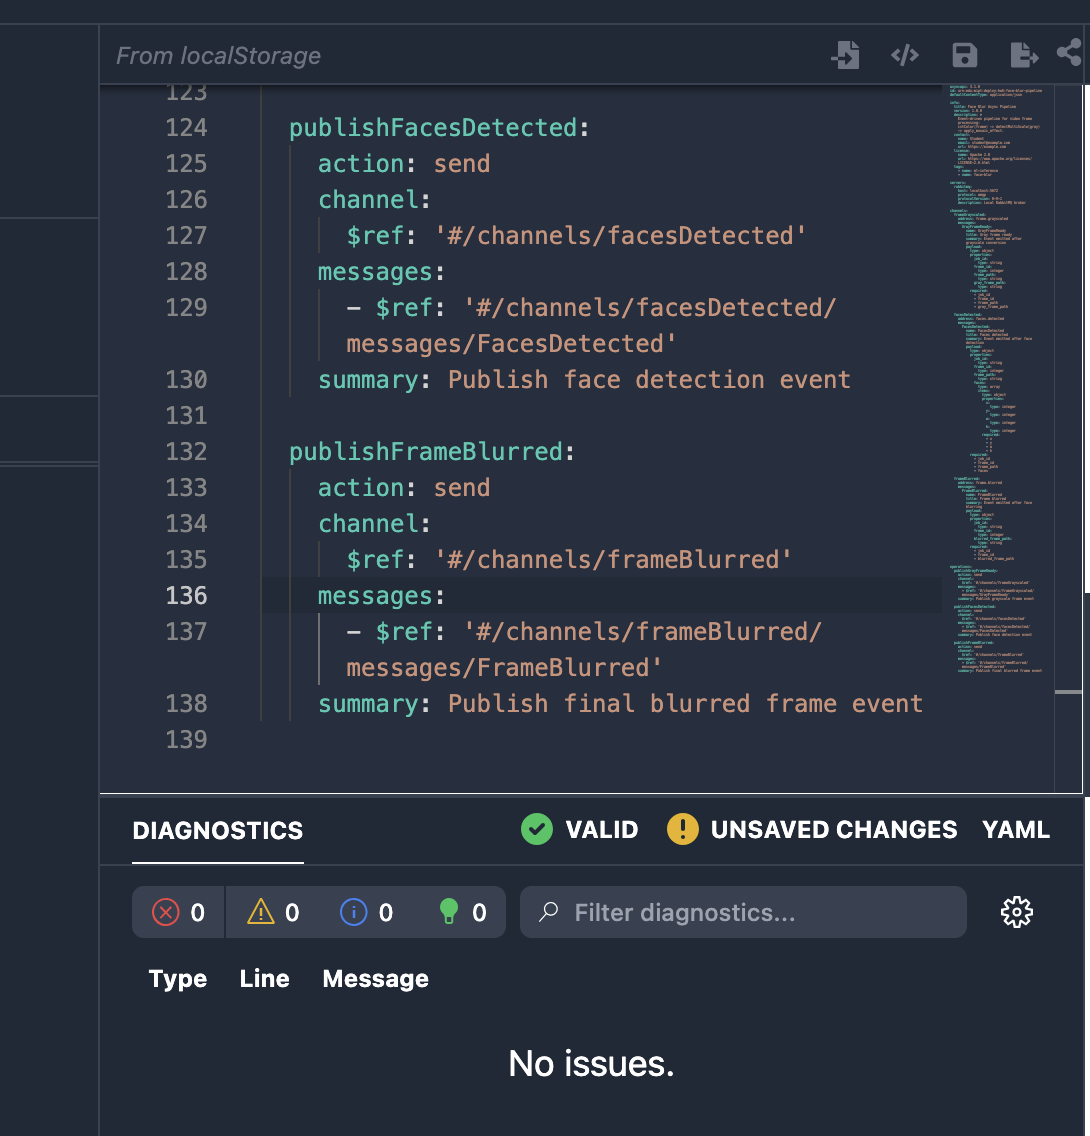

In [ ]:
%%writefile async.yaml
asyncapi: 3.1.0
id: urn:edu:mipt:deploy:hw6:face-blur-pipeline
defaultContentType: application/json

info:
  title: Face Blur Async Pipeline
  version: 1.0.0
  description: >
    Event-driven pipeline for video frame processing:
    cvtColor(frame) -> detectMultiScale(gray) -> apply_mosaic_effect.
  contact:
    name: Student
    email: student@example.com
    url: https://example.com
  license:
    name: Apache 2.0
    url: https://www.apache.org/licenses/LICENSE-2.0.html
  tags:
    - name: ml-inference
    - name: face-blur

servers:
  rabbitmq:
    host: localhost:5672
    protocol: amqp
    protocolVersion: 0-9-1
    description: Local RabbitMQ broker

channels:
  frameGrayscaled:
    address: frame.grayscaled
    messages:
      GrayFrameReady:
        name: GrayFrameReady
        title: Gray frame ready
        summary: Event emitted after grayscale conversion
        payload:
          type: object
          properties:
            job_id:
              type: string
            frame_id:
              type: integer
            frame_path:
              type: string
            gray_frame_path:
              type: string
          required:
            - job_id
            - frame_id
            - frame_path
            - gray_frame_path

  facesDetected:
    address: faces.detected
    messages:
      FacesDetected:
        name: FacesDetected
        title: Faces detected
        summary: Event emitted after face detection
        payload:
          type: object
          properties:
            job_id:
              type: string
            frame_id:
              type: integer
            frame_path:
              type: string
            faces:
              type: array
              items:
                type: object
                properties:
                  x:
                    type: integer
                  y:
                    type: integer
                  w:
                    type: integer
                  h:
                    type: integer
                required:
                  - x
                  - y
                  - w
                  - h
          required:
            - job_id
            - frame_id
            - frame_path
            - faces

  frameBlurred:
    address: frame.blurred
    messages:
      FrameBlurred:
        name: FrameBlurred
        title: Frame blurred
        summary: Event emitted after face blurring
        payload:
          type: object
          properties:
            job_id:
              type: string
            frame_id:
              type: integer
            blurred_frame_path:
              type: string
          required:
            - job_id
            - frame_id
            - blurred_frame_path

operations:
  publishGrayFrameReady:
    action: send
    channel:
      $ref: '#/channels/frameGrayscaled'
    messages:
      - $ref: '#/channels/frameGrayscaled/messages/GrayFrameReady'
    summary: Publish grayscale frame event

  publishFacesDetected:
    action: send
    channel:
      $ref: '#/channels/facesDetected'
    messages:
      - $ref: '#/channels/facesDetected/messages/FacesDetected'
    summary: Publish face detection event

  publishFrameBlurred:
    action: send
    channel:
      $ref: '#/channels/frameBlurred'
    messages:
      - $ref: '#/channels/frameBlurred/messages/FrameBlurred'
    summary: Publish final blurred frame event



Writing async.yaml


## 3. Выбрать стратегию (паттерн) загрузки моделей и реализовать ее

Вспомните [семинар](https://colab.research.google.com/drive/1MeNdQ0F_o4T85HKUQoyA8lhB-QUYqP24?usp=sharing), выберите **одну** стратегию загрузки моделей и напишите код для загрузки [модели](https://huggingface.co/cointegrated/rubert-tiny2)

*Ожидаемый артефакт: код в [ячейке](#scrollTo=X5IFDgIr35O5)*

In [1]:
from IPython.display import display
#!pip install ipywidgets
import ipywidgets as widgets
select_widget = widgets.Select(
    options=['Eager','Lazy','Pool','Hot Reload'],
    value='Lazy',
    description='Паттерн:',
    disabled=False
)
display(select_widget)
def on_value_change(change):
    print(f"Опишите в ячейке выше, почему выбран паттерн '{change['new']}', и реализуйте его")
select_widget.observe(on_value_change, names='value')
description_widget = widgets.Textarea(
    value='',
    placeholder='Опишите здесь, почему выбран паттерн',
    description='Обоснование:',
    disabled=False,
    layout=widgets.Layout(height='100px', width='auto')
)
display(description_widget)

Select(description='Паттерн:', index=1, options=('Eager', 'Lazy', 'Pool', 'Hot Reload'), value='Lazy')

Textarea(value='', description='Обоснование:', layout=Layout(height='100px', width='auto'), placeholder='Опиши…

Выбран паттерн Lazy Loading. Он загружает модель только при первом обращении и не расходует память во время простоя сервиса. По сравнению с Eager Loading такой подход лучше экономит ресурсы, хотя увеличивает задержку первого запроса. Варианты Pool и Hot Reload в данном случае избыточны, поскольку требуют более сложного сценария эксплуатации. Поэтому Lazy Loading лучше всего подходит для учебного сервиса с нерегулярными запросами.

In [5]:
# реализуйте паттерн здесь
#!pip install transformers
import time
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "cointegrated/rubert-tiny2"

class LazyModelLoader:
    def __init__(self, model_name):
        self.model_name = model_name
        self.tokenizer = None
        self.model = None

    def load(self):
        if self.model is None:
            print("Loading model for the first time...")
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModel.from_pretrained(self.model_name)
            self.model.eval()
            print("Model loaded.")
        return self.tokenizer, self.model

loader = LazyModelLoader(MODEL_NAME)

start_time = time.time()
tokenizer, model = loader.load()
first_latency = time.time() - start_time

start_time = time.time()
tokenizer, model = loader.load()
second_latency = time.time() - start_time

print("First load latency:", round(first_latency, 2), "seconds")
print("Second load latency:", round(second_latency, 2), "seconds")
print("Model class:", model.__class__.__name__)


Loading model for the first time...


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
First load latency: 1.87 seconds
Second load latency: 0.0 seconds
Model class: BertModel


Вывод: первая загрузка долгая, вторая почти мнгновенная, паттерн работает как задумано.

## 4. Создать загрузку данных  батчами в модель

Вспомните паттерн батчинга (Batching) из раздаточных материалов модуля и реализуйте его при условии, что длина буфера превышает 64 элемента или время ожидания превысило 30 секунд
```python
if len(buffer) >= 32 or timeout_reached(30):
```


*Ожидаемый артефакт: код в [ячейке](#scrollTo=U1qbvPfICwEi)*

In [7]:
import time
import torch

MAX_BATCH_SIZE = 64
MAX_WAIT_TIME = 30

# Используется LazyModelLoader из задания 3
batch_loader = LazyModelLoader(MODEL_NAME)

class BatchModelProcessor:
    def __init__(self, loader, max_batch_size=64, max_wait_time=30):
        self.loader = loader
        self.max_batch_size = max_batch_size
        self.max_wait_time = max_wait_time
        self.buffer = []
        self.first_item_time = None

    def process_batch(self, batch):
        tokenizer, model = self.loader.load()
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True
        )
        with torch.no_grad():
            outputs = model(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        print(f"Processing batch with {len(batch)} items")
        print("CLS embeddings shape:", tuple(cls_embeddings.shape))
        return cls_embeddings

    def flush(self):
        if not self.buffer:
            return None

        result = self.process_batch(self.buffer)
        self.buffer = []
        self.first_item_time = None
        return result

    def add_item(self, item):
        if not self.buffer:
            self.first_item_time = time.time()

        self.buffer.append(item)

        if len(self.buffer) >= self.max_batch_size:
            print("Batch triggered by size limit")
            return self.flush()

        return None

    def check_timeout(self):
        if not self.buffer:
            return None

        waiting_time = time.time() - self.first_item_time
        if waiting_time >= self.max_wait_time:
            print("Batch triggered by timeout")
            return self.flush()

        return None


processor = BatchModelProcessor(
    loader=batch_loader,
    max_batch_size=MAX_BATCH_SIZE,
    max_wait_time=MAX_WAIT_TIME
)

print(f"Configured batch size: {MAX_BATCH_SIZE}")
print(f"Configured timeout: {MAX_WAIT_TIME} seconds")

size_result = None
for i in range(MAX_BATCH_SIZE):
    size_result = processor.add_item(f"request {i}")

timeout_result = None
processor.add_item("timeout request")
print(f"Waiting {MAX_WAIT_TIME + 1} seconds to trigger timeout...")
time.sleep(MAX_WAIT_TIME + 1)
timeout_result = processor.check_timeout()

if size_result is not None:
    print("Size-trigger result shape:", tuple(size_result.shape))

if timeout_result is not None:
    print("Timeout-trigger result shape:", tuple(timeout_result.shape))


Configured batch size: 64
Configured timeout: 30 seconds
Batch triggered by size limit
Loading model for the first time...


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Processing batch with 64 items
CLS embeddings shape: (64, 312)
Waiting 31 seconds to trigger timeout...
Batch triggered by timeout
Processing batch with 1 items
CLS embeddings shape: (1, 312)
Size-trigger result shape: (64, 312)
Timeout-trigger result shape: (1, 312)


## 5. Создать онлайн-загрузку данных в модель

Вспомните асинхронный ML-сервис на связке Celery + RabbitMQ из раздаточных материалов модуля и реализуйте онлайн-загрузку данных в модель с помощью любого брокера.



*Ожидаемый артефакт: код в [ячейке](#scrollTo=FZiukZtfaCAY)*

In [ ]:
#%pip install pika

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%%bash
set -e

CONTAINER_NAME="hw6-rabbitmq"
IMAGE_NAME="rabbitmq:3-management"

if docker ps -a --format '{{.Names}}' | grep -qx "$CONTAINER_NAME"; then
  if [ "$(docker inspect -f '{{.State.Running}}' "$CONTAINER_NAME")" = "true" ]; then
    echo "RabbitMQ container is already running."
  else
    docker start "$CONTAINER_NAME"
    echo "RabbitMQ container has been started."
  fi
else
  docker run -d \
    --name "$CONTAINER_NAME" \
    -p 5672:5672 \
    -p 15672:15672 \
    "$IMAGE_NAME"
  echo "RabbitMQ container has been created and started."
fi

echo "AMQP endpoint: localhost:5672"
echo "Management UI: http://localhost:15672"
echo "Default credentials: guest / guest"

Unable to find image 'rabbitmq:3-management' locally
3-management: Pulling from library/rabbitmq
97dd3f0ce510: Pulling fs layer
4a669bc3e1dd: Pulling fs layer
908453a3b3f1: Pulling fs layer
dee3d7bda3a2: Pulling fs layer
b0dce9f9a25e: Pulling fs layer
4d707a369044: Pulling fs layer
ba58438a193e: Pulling fs layer
2b6c30257d7d: Pulling fs layer
c64be2c4c916: Pulling fs layer
e93d97eeeeb8: Pulling fs layer
b0dce9f9a25e: Waiting
2b6c30257d7d: Waiting
4d707a369044: Waiting
c64be2c4c916: Waiting
ba58438a193e: Waiting
e93d97eeeeb8: Waiting
dee3d7bda3a2: Waiting
908453a3b3f1: Verifying Checksum
908453a3b3f1: Download complete
dee3d7bda3a2: Verifying Checksum
dee3d7bda3a2: Download complete
97dd3f0ce510: Verifying Checksum
97dd3f0ce510: Download complete
97dd3f0ce510: Pull complete
4d707a369044: Verifying Checksum
4d707a369044: Download complete
ba58438a193e: Verifying Checksum
ba58438a193e: Download complete
2b6c30257d7d: Verifying Checksum
2b6c30257d7d: Download complete
c64be2c4c916: Verifyi

6c536e2d31de17ef5f8f7cceffb2a363534d68b62dd7667e2c10274c68b0196c
RabbitMQ container has been created and started.
AMQP: http://localhost:5672
Management UI: http://localhost:15672
Default credentials: guest / guest


In [10]:
import json
import time
import uuid
import threading
import pika

BROKER_HOST = "localhost"
REQUEST_QUEUE = "inference_requests"

worker_started = False

def create_connection():
    return pika.BlockingConnection(
        pika.ConnectionParameters(host=BROKER_HOST)
    )

def ensure_request_queue(channel):
    channel.queue_declare(queue=REQUEST_QUEUE, durable=True)

def run_worker():
    loader = LazyModelLoader(MODEL_NAME)

    connection = create_connection()
    channel = connection.channel()
    ensure_request_queue(channel)
    channel.basic_qos(prefetch_count=1)

    def callback(ch, method, properties, body):
        message = json.loads(body.decode())
        text = message["text"]

        tokenizer, model = loader.load()
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True
        )
        outputs = model(**inputs)
        sentence_embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0)

        response = {
            "request_id": message["request_id"],
            "text": text,
            "embedding_dim": int(sentence_embedding.shape[0]),
            "embedding_preview": [round(value, 4) for value in sentence_embedding[:5].tolist()]
        }

        ch.basic_publish(
            exchange="",
            routing_key=properties.reply_to,
            properties=pika.BasicProperties(
                correlation_id=properties.correlation_id
            ),
            body=json.dumps(response)
        )

        ch.basic_ack(delivery_tag=method.delivery_tag)
        print("Processed request:", message["request_id"])

    channel.basic_consume(
        queue=REQUEST_QUEUE,
        on_message_callback=callback
    )

    print("Worker is waiting for online requests...")
    channel.start_consuming()

def start_worker_in_background():
    global worker_started

    if worker_started:
        print("Worker is already running.")
        return

    worker_thread = threading.Thread(target=run_worker, daemon=True)
    worker_thread.start()
    time.sleep(2)

    worker_started = True
    print("Background worker started.")

def send_online_request(text, timeout=10):
    connection = create_connection()
    channel = connection.channel()
    ensure_request_queue(channel)

    callback_queue = channel.queue_declare(queue="", exclusive=True).method.queue
    request_id = str(uuid.uuid4())

    message = {
        "request_id": request_id,
        "text": text
    }

    channel.basic_publish(
        exchange="",
        routing_key=REQUEST_QUEUE,
        properties=pika.BasicProperties(
            reply_to=callback_queue,
            correlation_id=request_id,
            delivery_mode=2
        ),
        body=json.dumps(message)
    )

    start_time = time.time()

    while time.time() - start_time < timeout:
        method_frame, header_frame, body = channel.basic_get(
            queue=callback_queue,
            auto_ack=True
        )

        if body:
            response = json.loads(body.decode())
            if response["request_id"] == request_id:
                connection.close()
                return response

        time.sleep(0.2)

    connection.close()
    raise TimeoutError("No response received from worker.")

start_worker_in_background()

response = send_online_request(
    "RabbitMQ delivers this text to the online model worker."
)

print("Online inference response:", response)


Worker is waiting for online requests...
Background worker started.
Loading model for the first time...


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Processed request: a127c189-7ef6-4bcb-873f-69c6ecdf964f
Online inference response: {'request_id': 'a127c189-7ef6-4bcb-873f-69c6ecdf964f', 'text': 'RabbitMQ delivers this text to the online model worker.', 'embedding_dim': 312, 'embedding_preview': [-0.7872, -0.6318, 0.326, -1.4217, -0.7383]}


## 6. Итоговое оформление

Проще всего было описать цепочку событий в AsyncAPI. Сложнее всего оказался запуск локального окружения и очереди сообщений. Он же занял больше всего времени. Lazy Loading показал, что модель можно не держать в памяти постоянно, но первый запрос тогда работает медленнее. В целом стало ясно, что асинхронная обработка полезна для долгих задач и нескольких запросов одновременно.
